# Churn Telco — versão corrigida

**Pipeline sem vazamento · validação cruzada estratificada · painel de métricas completo · threshold por custo de retenção**

Esta é uma reconstrução do notebook `telco-customer-churn-svm-vs-randomforest`. A lógica de negócio é a mesma (prever cancelamento na base Telco, 7.043 clientes), mas a metodologia foi refeita nos pontos em que a versão original produzia conclusões que não se sustentam.

| # | Problema na versão original | Correção aqui |
|---|---|---|
| 1 | Avaliação só por **accuracy** numa base com 26,5% de churn (baseline trivial = 73,5%) | PR-AUC como métrica de seleção, mais painel com recall, precision, F1, ROC-AUC, calibração e ganho acumulado |
| 2 | `MinMaxScaler.fit_transform` no dataset **inteiro**, antes do split — vazamento | Todo o pré-processamento dentro de um `Pipeline`, ajustado apenas no treino de cada fold |
| 3 | Split único 80/20, sem estratificação e sem tuning; `RandomForestClassifier()` sem `random_state` — irreprodutível | `RepeatedStratifiedKFold` (5×3) para comparar, `GridSearchCV` para tunar, `random_state` fixo em tudo |
| 4 | Feature importance por impureza (enviesada para variáveis contínuas) | Permutation importance no conjunto de teste |
| 5 | `pickle` só do modelo, sem scaler nem ordem de colunas; nenhuma decisão de negócio | Pipeline inteiro serializado + threshold escolhido por lucro esperado + função de escoragem pronta |

**Spoiler dos resultados:** a configuração do notebook original (Random Forest default + SMOTE) é a **pior** de todas as testadas — 0,600 de PR-AUC contra 0,665 de uma Random Forest regularizada sem SMOTE. E o SMOTE, além de não melhorar o ranqueamento, destrói a calibração das probabilidades, que é justamente o que a decisão de negócio precisa.


## 1. Setup

In [1]:
import warnings, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, GridSearchCV,
                                     cross_validate, cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix,
                             classification_report, f1_score, accuracy_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

warnings.filterwarnings('ignore')
RS = 42                      # semente única, usada em TODO lugar
np.random.seed(RS)

# paleta categórica validada (colorblind-safe), tinta de texto e grid recessivo
AZUL, LARANJA, AQUA, VERMELHO = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
TINTA, TINTA2, GRID = '#0b0b0b', '#52514e', '#d8d8d4'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'axes.labelcolor': TINTA2, 'text.color': TINTA,
    'xtick.color': TINTA2, 'ytick.color': TINTA2, 'grid.color': GRID,
    'grid.linewidth': .8, 'axes.grid': True, 'axes.axisbelow': True,
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'legend.frameon': False, 'figure.facecolor': 'white'})
print('setup ok')

setup ok


## 2. Carga e limpeza determinística

Só entram aqui transformações **determinísticas** — regras fixas que não aprendem nada dos dados (converter tipo, corrigir um valor conhecido). Qualquer coisa que estime um parâmetro a partir da amostra (média, mínimo, máximo, frequência de categoria) fica para o pipeline, depois do split.

In [2]:
df = pd.read_csv('telco.csv')
print('shape bruto:', df.shape)

# TotalCharges vem como object por causa de 11 células em branco
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
brancos = df['TotalCharges'].isna()
print(f'\nRegistros com TotalCharges em branco: {brancos.sum()}')
print('tenure desses registros:', sorted(df.loc[brancos, "tenure"].unique()))
print('-> todos com tenure = 0 (cliente ainda não foi faturado). Zero é o valor correto, não uma imputação.')
df.loc[brancos & (df['tenure'] == 0), 'TotalCharges'] = 0.0

df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['customerID'])          # identificador, não é feature

print(f'\nshape final: {df.shape} | taxa de churn: {df["Churn"].mean():.2%}')
print(f'Baseline trivial ("ninguém cancela"): accuracy = {1 - df["Churn"].mean():.2%}')

shape bruto: (7043, 21)

Registros com TotalCharges em branco: 11
tenure desses registros: [0]
-> todos com tenure = 0 (cliente ainda não foi faturado). Zero é o valor correto, não uma imputação.

shape final: (7043, 20) | taxa de churn: 26.54%
Baseline trivial ("ninguém cancela"): accuracy = 73.46%


### Por que não recodificar `"No internet service"` para `"No"`

O notebook original faz isso. É defensável, mas descarta informação: *"não tem suporte técnico porque não contratou internet"* é um cliente diferente de *"tem internet e recusou suporte técnico"*. Aqui deixo as três categorias e o `OneHotEncoder` cria as colunas — o modelo decide se a distinção importa.

## 3. Split estratificado — **antes de qualquer coisa**

Esta é a linha divisória. Nada abaixo dela pode olhar para `X_test` até a hora da avaliação final: nem escalonamento, nem imputação, nem EDA, nem seleção de variáveis.

In [3]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols + ['Churn']]

X, y = df.drop(columns=['Churn']), df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RS)   # stratify garante 26,5% nos dois lados

print(f'treino: {X_train.shape[0]:5d} linhas | churn {y_train.mean():.2%}')
print(f'teste : {X_test.shape[0]:5d} linhas | churn {y_test.mean():.2%}')
print(f'\nnuméricas   ({len(num_cols)}): {num_cols}')
print(f'categóricas ({len(cat_cols)}): {cat_cols}')

treino:  5634 linhas | churn 26.54%
teste :  1409 linhas | churn 26.54%

numéricas   (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 4. EDA — apenas no conjunto de treino

Olhar a distribuição do alvo no dataset completo antes de decidir o que fazer também é uma forma (sutil) de vazamento: as escolhas de modelagem passam a ser informadas pelo teste. Por isso o EDA aqui usa `X_train` / `y_train`.

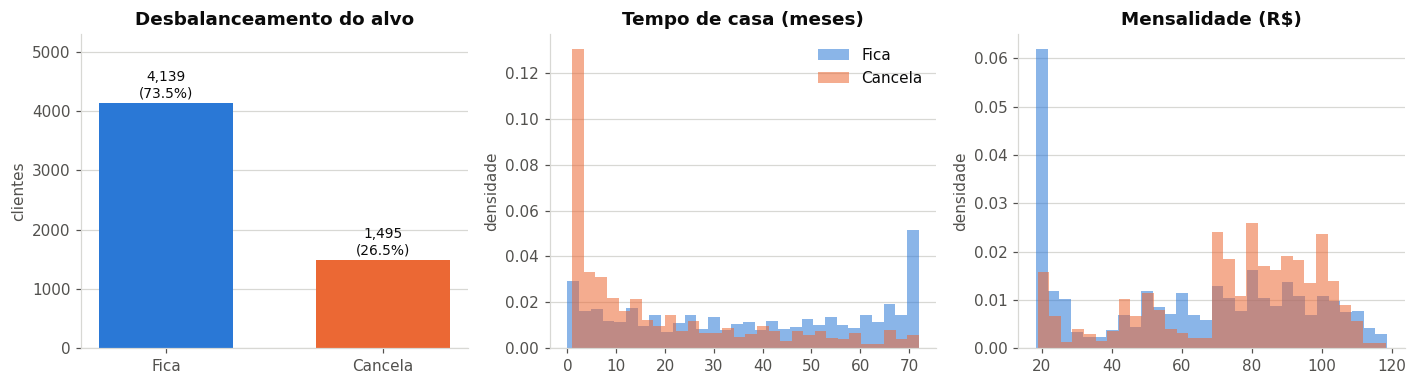

In [4]:
tr = X_train.copy(); tr['Churn'] = y_train

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# --- alvo: série única, sem legenda, rótulo direto
cont = tr['Churn'].value_counts().sort_index()
b = axes[0].bar(['Fica', 'Cancela'], cont.values, color=[AZUL, LARANJA], width=.62)
for r, v in zip(b, cont.values):
    axes[0].text(r.get_x() + r.get_width()/2, v + 40, f'{v:,}\n({v/cont.sum():.1%})',
                 ha='center', va='bottom', fontsize=9, color=TINTA)
axes[0].set_title('Desbalanceamento do alvo'); axes[0].set_ylim(0, cont.max()*1.28)
axes[0].grid(axis='x', visible=False); axes[0].set_ylabel('clientes')

# --- tenure e MonthlyCharges por churn: 2 séries, legenda presente
for ax, col, titulo in [(axes[1], 'tenure', 'Tempo de casa (meses)'),
                        (axes[2], 'MonthlyCharges', 'Mensalidade (R$)')]:
    for lab, cor in [('Fica', AZUL), ('Cancela', LARANJA)]:
        d = tr.loc[tr['Churn'] == (lab == 'Cancela'), col]
        ax.hist(d, bins=30, density=True, alpha=.55, color=cor, label=lab)
    ax.set_title(titulo); ax.set_ylabel('densidade'); ax.grid(axis='x', visible=False)
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

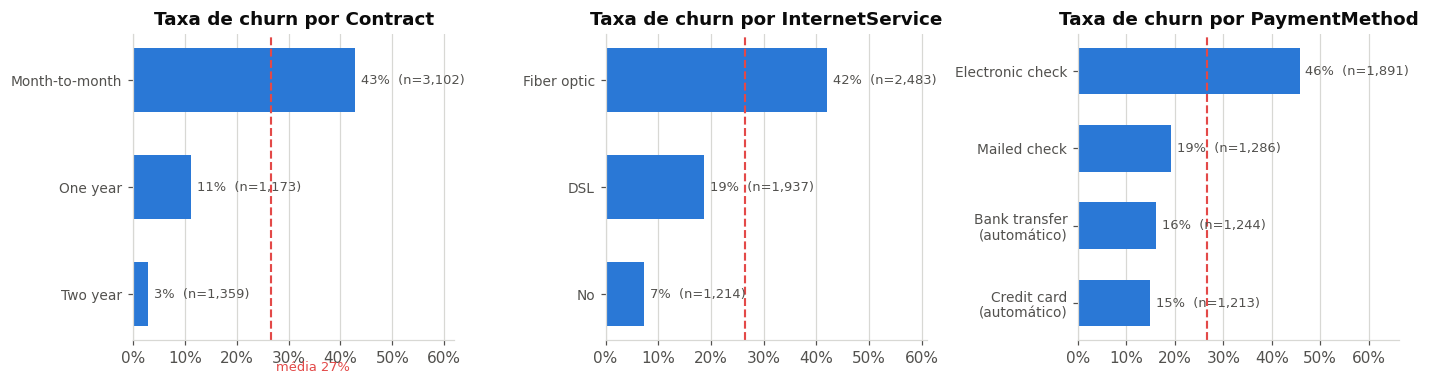

In [5]:
# taxa de churn por categoria — o que realmente separa os grupos
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    taxa = tr.groupby(col)['Churn'].agg(['mean', 'size']).sort_values('mean')
    b = ax.barh(range(len(taxa)), taxa['mean'], color=AZUL, height=.6)
    ax.set_yticks(range(len(taxa)))
    ax.set_yticklabels([t.replace(' (automatic)', '\n(automático)') for t in taxa.index], fontsize=9)
    for i, (m, n) in enumerate(zip(taxa['mean'], taxa['size'])):
        ax.text(m + .012, i, f'{m:.0%}  (n={n:,})', va='center', fontsize=8.5, color=TINTA2)
    ax.axvline(y_train.mean(), color=VERMELHO, lw=1.4, ls='--')
    ax.set_xlim(0, max(taxa['mean'])*1.45)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(f'Taxa de churn por {col}'); ax.grid(axis='y', visible=False)
axes[0].text(y_train.mean()+.01, -.72, f'média {y_train.mean():.0%}', color=VERMELHO, fontsize=8.5)
plt.tight_layout(); plt.show()

Contrato mensal (~43% de churn contra 3% no contrato de 2 anos), fibra óptica e pagamento por cheque eletrônico são os três marcadores fortes — consistente com o notebook original. A diferença é que agora esses números vêm só do treino.

## 5. O pipeline — onde o vazamento deixa de existir

Tudo o que **aprende parâmetros** (média e desvio do scaler, categorias do encoder, vizinhos sintéticos do SMOTE) fica dentro do `Pipeline`. Quando o `cross_validate` divide os dados, cada fold refaz esse ajuste usando só a sua parte de treino. É estruturalmente impossível o scaler enxergar o conjunto de validação.

Uso `imblearn.pipeline.Pipeline` em vez do `sklearn`: ele garante que o SMOTE rode **só no `fit`**, nunca no `transform` — ou seja, o fold de validação nunca recebe linhas sintéticas.

In [6]:
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols)])

def montar(clf, smote=False):
    """Pipeline completo. smote=True insere o oversampling APÓS o pré-processamento
    e apenas na etapa de fit."""
    passos = [('pre', pre)]
    if smote:
        passos.append(('smote', SMOTE(random_state=RS)))
    passos.append(('clf', clf))
    return ImbPipeline(passos)

montar(LogisticRegression(), smote=True)

,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given st

## 6. Comparação de modelos com validação cruzada estratificada repetida

Uma partição única não permite dizer que um modelo é melhor que outro — a diferença observada pode ser ruído da amostra. Uso `RepeatedStratifiedKFold(5 folds × 3 repetições)` = 15 medições por modelo, e reporto **média ± desvio**.

**Métrica de seleção: PR-AUC (average precision).** Em base desbalanceada, a ROC-AUC é otimista porque o denominador da taxa de falso-positivo é a classe majoritária, que é enorme. A PR-AUC olha só para a qualidade do ranqueamento entre os churners — que é o que a campanha de retenção usa. Reporto também o **Brier score** (erro quadrático da probabilidade), que mede calibração: quanto menor, mais confiáveis são as probabilidades para a decisão de custo.

Incluí de propósito a configuração exata do notebook original como linha de comparação.

In [7]:
candidatos = {
    'Baseline (prevalência)':
        montar(DummyClassifier(strategy='prior', random_state=RS)),
    'Regressão Logística':
        montar(LogisticRegression(max_iter=2000, C=1.0, random_state=RS)),
    'Random Forest (regularizada)':
        montar(RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                      random_state=RS, n_jobs=-1)),
    'Random Forest (class_weight)':
        montar(RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                      class_weight='balanced', random_state=RS, n_jobs=-1)),
    'Gradient Boosting':
        montar(HistGradientBoostingClassifier(max_leaf_nodes=15, learning_rate=.05,
                                              max_iter=300, l2_regularization=1., random_state=RS)),
    'SVM RBF + SMOTE  (orig.)':
        montar(SVC(C=1.0, probability=True, random_state=RS), smote=True),
    'RF default + SMOTE  (orig.)':
        montar(RandomForestClassifier(random_state=RS, n_jobs=-1), smote=True),
}

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RS)
linhas = []
for nome, pipe in candidatos.items():
    r = cross_validate(pipe, X_train, y_train, cv=rcv, n_jobs=-1,
                       scoring=['average_precision', 'roc_auc', 'neg_brier_score'])
    linhas.append({'Modelo': nome,
                   'PR-AUC': r['test_average_precision'].mean(),
                   '± dp':   r['test_average_precision'].std(),
                   'ROC-AUC': r['test_roc_auc'].mean(),
                   'Brier':  -r['test_neg_brier_score'].mean()})
    print(f'{nome:30s} PR-AUC {linhas[-1]["PR-AUC"]:.4f} ± {linhas[-1]["± dp"]:.4f}')

cv_res = pd.DataFrame(linhas).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
cv_res.style.format({'PR-AUC':'{:.4f}', '± dp':'{:.4f}', 'ROC-AUC':'{:.4f}', 'Brier':'{:.4f}'})

Baseline (prevalência)         PR-AUC 0.2654 ± 0.0001


Regressão Logística            PR-AUC 0.6612 ± 0.0171


Random Forest (regularizada)   PR-AUC 0.6649 ± 0.0216


Random Forest (class_weight)   PR-AUC 0.6640 ± 0.0200


Gradient Boosting              PR-AUC 0.6590 ± 0.0198


SVM RBF + SMOTE  (orig.)       PR-AUC 0.6115 ± 0.0199


RF default + SMOTE  (orig.)    PR-AUC 0.5995 ± 0.0312


,Modelo,PR-AUC,± dp,ROC-AUC,Brier
0,Random Forest (regularizada),0.6649,0.0216,0.8486,0.1343
1,Random Forest (class_weight),0.6640,0.0200,0.8488,0.1551
2,Regressão Logística,0.6612,0.0171,0.8463,0.1350
3,Gradient Boosting,0.6590,0.0198,0.8426,0.1366
4,SVM RBF + SMOTE (orig.),0.6115,0.0199,0.8265,0.1597
5,RF default + SMOTE (orig.),0.5995,0.0312,0.8219,0.1509
6,Baseline (prevalência),0.2654,0.0001,0.5000,0.1949


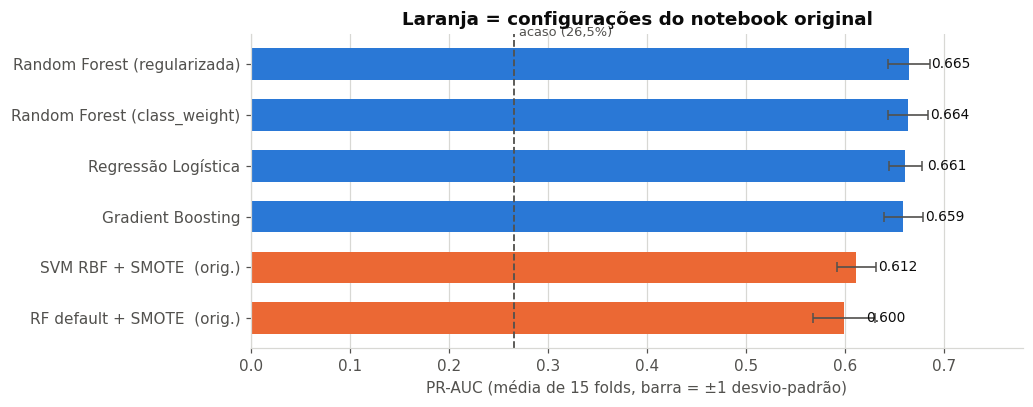

In [8]:
d = cv_res[cv_res['Modelo'] != 'Baseline (prevalência)'].sort_values('PR-AUC')
cores = [LARANJA if '(orig.)' in m else AZUL for m in d['Modelo']]
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.barh(range(len(d)), d['PR-AUC'], xerr=d['± dp'], color=cores, height=.62,
        error_kw=dict(ecolor=TINTA2, lw=1.1, capsize=3))
ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Modelo'])
for i, v in enumerate(d['PR-AUC']):
    ax.text(v + .022, i, f'{v:.3f}', va='center', fontsize=9, color=TINTA)
ax.axvline(y_train.mean(), color=TINTA2, ls='--', lw=1.2)
ax.text(y_train.mean()+.005, len(d)-.45, 'acaso (26,5%)', fontsize=8.5, color=TINTA2)
ax.set_xlim(0, .78); ax.set_xlabel('PR-AUC (média de 15 folds, barra = ±1 desvio-padrão)')
ax.set_title('Laranja = configurações do notebook original'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### Leitura

1. **As três primeiras configurações são indistinguíveis.** A diferença entre elas (~0,005 de PR-AUC) é um quarto do desvio entre folds (~0,020). Afirmar "Random Forest ganha da Regressão Logística" com esses números não se sustenta.
2. **As duas configurações do notebook original ficam claramente atrás** — ~0,05 a 0,065 abaixo do topo, o que é 2,5 a 3 desvios-padrão. Essa diferença é real.
3. **O SMOTE é o principal culpado.** A mesma Random Forest, tirando o SMOTE e regularizando (`max_depth=8`, `min_samples_leaf=5`), sobe de 0,60 para 0,66. O SMOTE cria vizinhos sintéticos interpolando entre churners; num espaço dominado por variáveis binárias one-hot, essas interpolações caem em pontos que não correspondem a nenhum cliente possível (por exemplo "40% fibra óptica").
4. **A comparação central do notebook original se inverte.** Lá, RF (0,777 de accuracy) "ganhava" do SVM (0,763). Aqui, medindo o que importa e com 15 folds, o SVM+SMOTE (0,612) fica **acima** do RF default+SMOTE (0,600) — a pior configuração de todas é justamente a que o original elegeu como vencedora. As duas estão mal configuradas, e a diferença entre elas nunca foi grande o bastante para sustentar um veredito.

### O que o SMOTE faz com a calibração

Este é o ponto que inviabiliza o SMOTE para o nosso objetivo. A decisão de contatar ou não um cliente depende da **probabilidade prevista**, não do rótulo. Se o modelo aprendeu numa base artificialmente 50/50, ele devolve probabilidades infladas.

Sem SMOTE  prob. média prevista = 0.266  (churn real = 0.265)


Com SMOTE  prob. média prevista = 0.402  (churn real = 0.265)


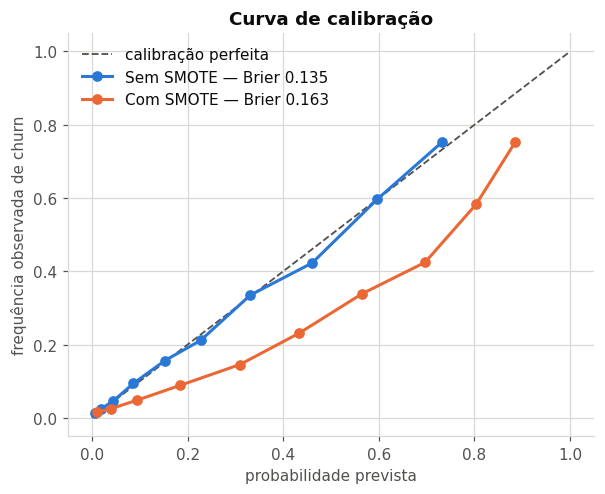

In [9]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=RS)
comparacao = {
    'Sem SMOTE': montar(LogisticRegression(max_iter=2000, random_state=RS)),
    'Com SMOTE': montar(LogisticRegression(max_iter=2000, random_state=RS), smote=True)}

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0,1],[0,1], color=TINTA2, ls='--', lw=1.2, label='calibração perfeita')
for (nome, pipe), cor in zip(comparacao.items(), [AZUL, LARANJA]):
    p = cross_val_predict(pipe, X_train, y_train, cv=cv5, method='predict_proba')[:, 1]
    fx, fy = calibration_curve(y_train, p, n_bins=10, strategy='quantile')
    ax.plot(fy, fx, 'o-', color=cor, lw=2, ms=6,
            label=f'{nome} — Brier {brier_score_loss(y_train, p):.3f}')
    print(f'{nome:10s} prob. média prevista = {p.mean():.3f}  (churn real = {y_train.mean():.3f})')
ax.set_xlabel('probabilidade prevista'); ax.set_ylabel('frequência observada de churn')
ax.set_title('Curva de calibração'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

O modelo com SMOTE prevê churn médio de ~40% numa base onde ele é 26,5% — a curva inteira fica abaixo da diagonal, ou seja, **superestima o risco sistematicamente**. Um threshold escolhido por custo em cima dessas probabilidades aponta para o cliente errado. Sem SMOTE, a probabilidade média bate com a realidade e a curva gruda na diagonal.

**Decisão: seguir sem SMOTE**, usando a Random Forest regularizada (melhor PR-AUC e Brier equivalente ao da logística).

## 7. Tuning do finalista

`GridSearchCV` sobre o pipeline inteiro — cada combinação é reavaliada com o pré-processamento refeito por fold.

In [10]:
grid = {'clf__n_estimators': [400],
        'clf__max_depth': [6, 8, 12, None],
        'clf__min_samples_leaf': [1, 5, 10],
        'clf__max_features': ['sqrt', 0.4]}

gs = GridSearchCV(montar(RandomForestClassifier(random_state=RS, n_jobs=-1)),
                  grid, scoring='average_precision',
                  cv=StratifiedKFold(5, shuffle=True, random_state=RS),
                  n_jobs=-1, refit=True)
gs.fit(X_train, y_train)
print('melhores hiperparâmetros:', gs.best_params_)
print(f'PR-AUC (CV): {gs.best_score_:.4f}')
modelo = gs.best_estimator_

# Predições out-of-fold do TREINO — é a partir daqui que qualquer threshold será escolhido.
# Uso uma partição DIFERENTE da que serviu ao GridSearchCV (RS+7): reaproveitar as mesmas
# dobras deixaria o OOF otimista, já que os hiperparâmetros foram escolhidos nelas.
cv_thr = StratifiedKFold(5, shuffle=True, random_state=RS + 7)
p_oof = cross_val_predict(modelo, X_train, y_train, cv=cv_thr, method='predict_proba')[:, 1]
print(f'PR-AUC out-of-fold (partição independente): {average_precision_score(y_train, p_oof):.4f}')

melhores hiperparâmetros: {'clf__max_depth': 8, 'clf__max_features': 0.4, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 400}
PR-AUC (CV): 0.6665


PR-AUC out-of-fold (partição independente): 0.6678


## 8. Painel de métricas no conjunto de teste

O teste é usado **uma única vez**, aqui. Nada acima foi decidido olhando para ele.

In [11]:
p_test = modelo.predict_proba(X_test)[:, 1]
prev = y_test.mean()

print(f'{"":28s}{"modelo":>10s}{"baseline":>12s}')
print(f'{"PR-AUC (average precision)":28s}{average_precision_score(y_test, p_test):>10.4f}{prev:>12.4f}')
print(f'{"ROC-AUC":28s}{roc_auc_score(y_test, p_test):>10.4f}{0.5:>12.4f}')
print(f'{"Brier score (menor=melhor)":28s}{brier_score_loss(y_test, p_test):>10.4f}'
      f'{brier_score_loss(y_test, np.full(len(y_test), prev)):>12.4f}')
print(f'{"Accuracy @ 0.50":28s}{accuracy_score(y_test, p_test>=.5):>10.4f}{1-prev:>12.4f}')
print('\n--- classification report no threshold 0.50 (o default que o notebook original usa) ---')
print(classification_report(y_test, (p_test>=.5).astype(int),
                            target_names=['Fica','Cancela'], digits=3))

                                modelo    baseline


PR-AUC (average precision)      0.6545      0.2654
ROC-AUC                         0.8442      0.5000
Brier score (menor=melhor)      0.1359      0.1950
Accuracy @ 0.50                 0.7991      0.7346

--- classification report no threshold 0.50 (o default que o notebook original usa) ---
              precision    recall  f1-score   support

        Fica      0.840     0.898     0.868      1035
     Cancela      0.650     0.527     0.582       374

    accuracy                          0.799      1409
   macro avg      0.745     0.712     0.725      1409
weighted avg      0.790     0.799     0.792      1409



A leitura crítica: **accuracy 0,80 parece ótima até você comparar com o baseline de 0,735** — são 6 pontos de ganho sobre não fazer nada. E o recall da classe que interessa fica em torno de 0,53 — metade dos clientes que vão cancelar passa despercebida no threshold padrão. É exatamente essa informação que a métrica única do notebook original escondia.

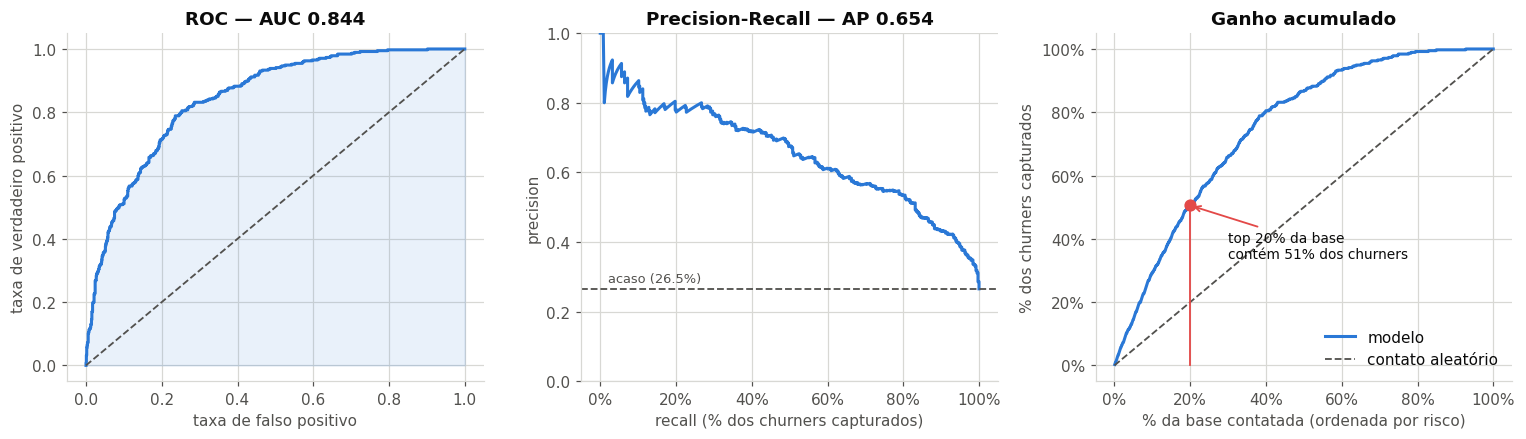

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))

# --- ROC
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, color=AZUL, lw=2)
axes[0].plot([0,1],[0,1], color=TINTA2, ls='--', lw=1.2)
axes[0].fill_between(fpr, tpr, alpha=.10, color=AZUL)
axes[0].set_title(f'ROC — AUC {roc_auc_score(y_test, p_test):.3f}')
axes[0].set_xlabel('taxa de falso positivo'); axes[0].set_ylabel('taxa de verdadeiro positivo')

# --- Precision-Recall
pr, rc, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(rc, pr, color=AZUL, lw=2)
axes[1].axhline(prev, color=TINTA2, ls='--', lw=1.2)
axes[1].text(.02, prev+.02, f'acaso ({prev:.1%})', fontsize=8.5, color=TINTA2)
axes[1].set_title(f'Precision-Recall — AP {average_precision_score(y_test, p_test):.3f}')
axes[1].set_xlabel('recall (% dos churners capturados)'); axes[1].set_ylabel('precision')
axes[1].set_ylim(0, 1)

# --- ganho acumulado (a leitura de campanha)
ordem = np.argsort(-p_test)
ganho = np.cumsum(y_test.values[ordem]) / y_test.sum()
pct = np.arange(1, len(y_test)+1) / len(y_test)
axes[2].plot(pct, ganho, color=AZUL, lw=2, label='modelo')
axes[2].plot([0,1],[0,1], color=TINTA2, ls='--', lw=1.2, label='contato aleatório')
i20 = int(.2*len(pct))
axes[2].plot([.2,.2],[0,ganho[i20]], color=VERMELHO, lw=1.2)
axes[2].plot(.2, ganho[i20], 'o', color=VERMELHO, ms=7)
axes[2].annotate(f'top 20% da base\ncontém {ganho[i20]:.0%} dos churners',
                 xy=(.2, ganho[i20]), xytext=(.30, .34), fontsize=9, color=TINTA,
                 arrowprops=dict(arrowstyle='->', color=VERMELHO, lw=1.2))
axes[2].set_title('Ganho acumulado'); axes[2].legend(loc='lower right')
axes[2].set_xlabel('% da base contatada (ordenada por risco)'); axes[2].set_ylabel('% dos churners capturados')
for a in axes[1:]: a.xaxis.set_major_formatter(PercentFormatter(1))
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

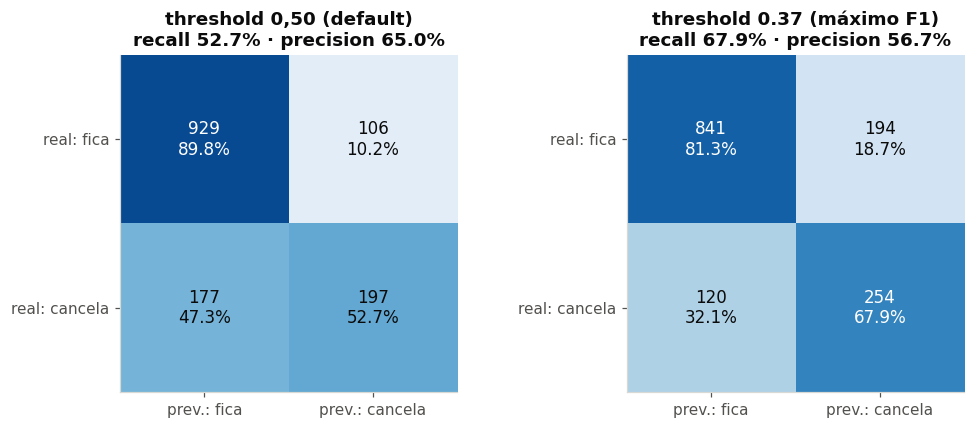

Threshold que maximiza F1: 0.37 — mas F1 é uma métrica de conveniência.
A escolha correta do threshold é econômica, não estatística. É o que a seção 10 faz.


In [13]:
# matriz de confusão em dois thresholds — sequencial de um tom só
def plot_cm(ax, t, titulo):
    cm = confusion_matrix(y_test, (p_test >= t).astype(int))
    ax.imshow(cm/cm.sum(axis=1, keepdims=True), cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            frac = cm[i,j]/cm[i].sum()
            ax.text(j, i, f'{cm[i,j]:,}\n{frac:.1%}', ha='center', va='center',
                    fontsize=11, color='white' if frac > .55 else TINTA)
    ax.set_xticks([0,1], ['prev.: fica','prev.: cancela'])
    ax.set_yticks([0,1], ['real: fica','real: cancela'])
    rec = cm[1,1]/cm[1].sum(); prc = cm[1,1]/max(cm[:,1].sum(),1)
    ax.set_title(f'{titulo}\nrecall {rec:.1%} · precision {prc:.1%}')
    ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
plot_cm(axes[0], .5, 'threshold 0,50 (default)')
lim_f1 = np.linspace(.05,.95,91)
# escolhido no OOF do TREINO — o teste não participa de nenhuma decisão
t_f1 = lim_f1[int(np.argmax([f1_score(y_train, p_oof>=t) for t in lim_f1]))]
plot_cm(axes[1], t_f1, f'threshold {t_f1:.2f} (máximo F1)')
plt.tight_layout(); plt.show()
print(f'Threshold que maximiza F1: {t_f1:.2f} — mas F1 é uma métrica de conveniência.')
print('A escolha correta do threshold é econômica, não estatística. É o que a seção 10 faz.')

## 9. Importância das variáveis — permutation, não impureza

O `feature_importances_` da Random Forest mede redução de impureza e é **enviesado para variáveis com muitos valores distintos**: `tenure`, `MonthlyCharges` e `TotalCharges` dominam por construção, não necessariamente por relevância. A permutation importance mede o que de fato importa: quanto a PR-AUC **no teste** cai quando você embaralha aquela coluna.

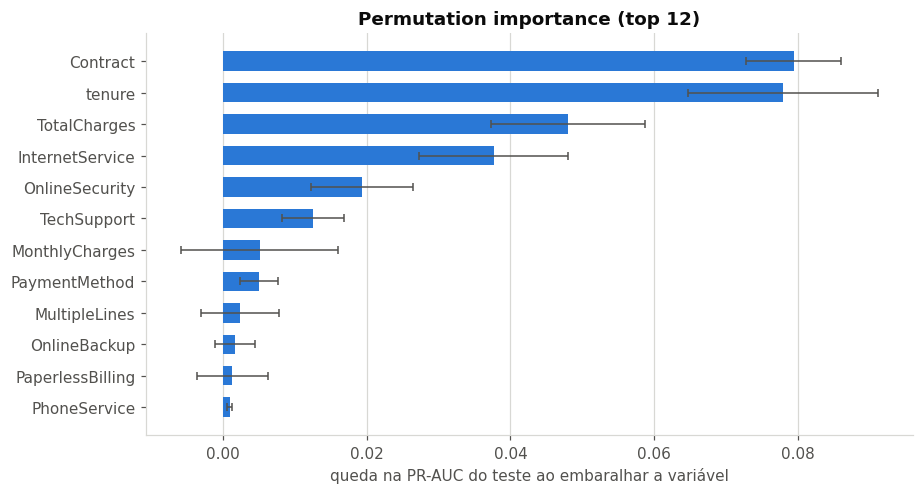

Comparação com o método que o notebook original usa (impureza):
cat__Contract_Month-to-month        0.2179
num__tenure                         0.1437
num__TotalCharges                   0.1152
num__MonthlyCharges                 0.0907
cat__OnlineSecurity_No              0.0857
cat__InternetService_Fiber optic    0.0690


In [14]:
perm = permutation_importance(modelo, X_test, y_test, n_repeats=15,
                              random_state=RS, scoring='average_precision', n_jobs=-1)
imp = (pd.DataFrame({'variavel': X_test.columns,
                     'queda': perm.importances_mean, 'dp': perm.importances_std})
       .sort_values('queda', ascending=False).head(12).iloc[::-1])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(range(len(imp)), imp['queda'], xerr=imp['dp'], color=AZUL, height=.62,
        error_kw=dict(ecolor=TINTA2, lw=1, capsize=2.5))
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp['variavel'])
ax.set_xlabel('queda na PR-AUC do teste ao embaralhar a variável')
ax.set_title('Permutation importance (top 12)'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

print('Comparação com o método que o notebook original usa (impureza):')
nomes_pre = modelo.named_steps['pre'].get_feature_names_out()
gini = pd.Series(modelo.named_steps['clf'].feature_importances_, index=nomes_pre)
print(gini.sort_values(ascending=False).head(6).round(4).to_string())

## 10. Threshold por custo de retenção

Aqui o modelo vira decisão. Um classificador entrega uma probabilidade; **o threshold é uma escolha de negócio**, não um default de biblioteca. 0,50 só é ótimo quando errar para mais e errar para menos custam a mesma coisa — o que em churn nunca acontece.

### Premissas (derivadas da própria base)

| Parâmetro | Valor | Justificativa |
|---|---|---|
| Valor em risco por cliente | `MonthlyCharges × 12` | receita anual que se perde se ele cancelar |
| Custo da oferta de retenção | `2 × MonthlyCharges` | desconto equivalente a 2 mensalidades, dado a todo cliente contatado |
| Custo operacional do contato | `R$ 30` | ligação / campanha, fixo por cliente contatado |
| Taxa de sucesso da retenção | `30%` | dos churners contatados, 30% são efetivamente salvos |

O lucro de contatar o cliente *i*, em relação a não fazer nada, é

$$\text{lucro}_i = \underbrace{-\,(30 + 2M_i)}_{\text{sempre pago}} \;+\; \underbrace{y_i \cdot 0{,}30 \cdot 12M_i}_{\text{só se ele ia mesmo cancelar}}$$

Falso negativo custa 0 explícito (perde-se a receita, mas isso já é o cenário-base). Falso positivo custa o valor da oferta jogado num cliente que ficaria de qualquer jeito.

**Ponto crítico:** o threshold é escolhido em predições *out-of-fold do treino*, nunca no teste. Escolher o threshold olhando o teste é a mesma classe de erro que escalonar antes do split.

In [15]:
S_SUCESSO   = 0.30   # taxa de sucesso da retenção
MESES_OFERTA = 2.0   # custo da oferta, em mensalidades
CUSTO_FIXO   = 30.0  # custo operacional do contato, R$

def economia(prob, y_real, mensalidade, threshold, s=S_SUCESSO,
             meses=MESES_OFERTA, fixo=CUSTO_FIXO):
    """Lucro total da campanha vs. não fazer nada."""
    contatar = prob >= threshold
    valor  = mensalidade * 12
    custo  = fixo + meses * mensalidade
    lucro  = (-custo[contatar]).sum() + (s * valor[contatar] * y_real[contatar]).sum()
    return float(lucro), int(contatar.sum())

# p_oof (seção 7) são as probabilidades out-of-fold do TREINO -> é nelas que o threshold é escolhido
m_train = X_train['MonthlyCharges'].values
m_test  = X_test['MonthlyCharges'].values
y_te    = y_test.values

grade  = np.linspace(0.01, 0.99, 197)
lucros_oof = np.array([economia(p_oof, y_train.values, m_train, t)[0] for t in grade])
T_OTIMO = grade[int(np.argmax(lucros_oof))]
print(f'Threshold ótimo (escolhido no out-of-fold do treino): {T_OTIMO:.3f}')
print(f'  -> bem longe do default 0,50, e do 0,{t_f1*100:.0f} que maximiza F1')

Threshold ótimo (escolhido no out-of-fold do treino): 0.640
  -> bem longe do default 0,50, e do 0,37 que maximiza F1


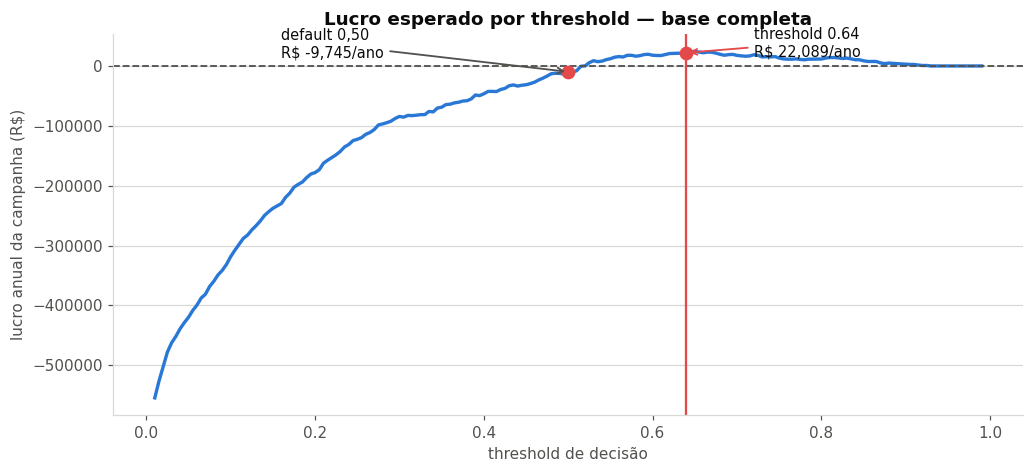

In [16]:
lucros_test = np.array([economia(p_test, y_te, m_test, t)[0] for t in grade])
escala = len(df) / len(y_test)     # o teste é 20% da base; extrapolar para a base inteira

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(grade, lucros_test*escala, color=AZUL, lw=2.2)
ax.axhline(0, color=TINTA2, lw=1.2, ls='--')
ax.axvline(T_OTIMO, color=VERMELHO, lw=1.5)
l_ot = economia(p_test, y_te, m_test, T_OTIMO)[0]*escala
l_50 = economia(p_test, y_te, m_test, 0.50)[0]*escala
ax.plot([T_OTIMO, .50], [l_ot, l_50], 'o', color=VERMELHO, ms=8)
ax.annotate(f'threshold {T_OTIMO:.2f}\nR$ {l_ot:,.0f}/ano', xy=(T_OTIMO, l_ot),
            xytext=(T_OTIMO+.08, l_ot*.75), fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle='->', color=VERMELHO, lw=1.2))
ax.annotate(f'default 0,50\nR$ {l_50:,.0f}/ano', xy=(.50, l_50),
            xytext=(.16, l_ot*.62), fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle='->', color=TINTA2, lw=1.2))
ax.set_xlabel('threshold de decisão'); ax.set_ylabel('lucro anual da campanha (R$)')
ax.set_title('Lucro esperado por threshold — base completa')
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

### Regra por cliente: um threshold só é o segundo melhor

Como custo e valor variam com a mensalidade, o threshold que faz sentido **varia por cliente**. Contatar o cliente *i* vale a pena quando o retorno esperado supera o custo:

$$p_i \cdot 0{,}30 \cdot 12 M_i \;>\; 30 + 2 M_i \quad\Longleftrightarrow\quad p_i \;>\; \frac{30 + 2M_i}{3{,}6\,M_i}$$

Para uma mensalidade de R$ 100 o corte é 0,64; para R$ 20 ele é 1,01 — ou seja, **cliente barato não vale campanha nenhuma**, por mais provável que seja o cancelamento. O custo fixo do contato come toda a margem.

In [17]:
valor_te = m_test * 12
custo_te = CUSTO_FIXO + MESES_OFERTA * m_test
thr_ind  = custo_te / (S_SUCESSO * valor_te)          # threshold individual
sel_ind  = p_test >= thr_ind
lucro_ind = float((-custo_te[sel_ind]).sum() + (S_SUCESSO*valor_te[sel_ind]*y_te[sel_ind]).sum())

cenarios = []
for nome, (l, n) in {
    'Não fazer nada':                         (0.0, 0),
    'Contatar todos':                          economia(p_test, y_te, m_test, 0.0),
    'Contatar top 20% de risco':               economia(p_test, y_te, m_test, np.quantile(p_test, .8)),
    'Threshold 0,50 (default)':                economia(p_test, y_te, m_test, .50),
    f'Threshold {T_OTIMO:.2f} (ótimo global)'.replace('.', ','): economia(p_test, y_te, m_test, T_OTIMO),
    'Regra por cliente (valor esperado)':      (lucro_ind, int(sel_ind.sum())),
}.items():
    cenarios.append({'Estratégia': nome, 'Contatados': n,
                     '% da base': n/len(y_te), 'Lucro anual (R$)': l*escala})
res_econ = pd.DataFrame(cenarios)
res_econ.style.format({'% da base':'{:.1%}', 'Lucro anual (R$)':'R$ {:,.0f}',
                       'Contatados':'{:,.0f}'}).hide(axis='index')

Estratégia,Contatados,% da base,Lucro anual (R$)
Não fazer nada,0,0.0%,R$ 0
Contatar todos,"1,409",100.0%,"R$ -624,317"
Contatar top 20% de risco,282,20.0%,R$ -561
"Threshold 0,50 (default)",303,21.5%,"R$ -9,745"
"Threshold 0,64 (ótimo global)",141,10.0%,"R$ 22,089"
Regra por cliente (valor esperado),128,9.1%,"R$ 23,634"


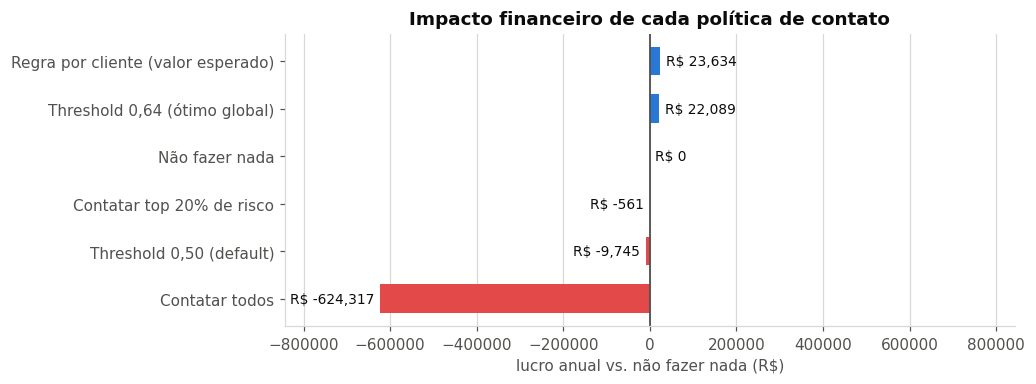

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
d = res_econ.sort_values('Lucro anual (R$)')
cores = [VERMELHO if v < 0 else AZUL for v in d['Lucro anual (R$)']]
ax.barh(range(len(d)), d['Lucro anual (R$)'], color=cores, height=.6)
ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Estratégia'])
lim = max(abs(d['Lucro anual (R$)']))
for i, v in enumerate(d['Lucro anual (R$)']):
    ax.text(v + (lim*.02 if v >= 0 else -lim*.02), i, f'R$ {v:,.0f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA2, lw=1.2)
ax.set_xlim(-lim*1.35, lim*1.35); ax.set_xlabel('lucro anual vs. não fazer nada (R$)')
ax.set_title('Impacto financeiro de cada política de contato'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### A conclusão desconfortável — e por que ela é o resultado mais valioso do notebook

Com estas premissas, **contatar todo mundo destrói valor** (prejuízo de seis dígitos: você dá 2 mensalidades de desconto para milhares de clientes que ficariam de graça). O threshold ótimo contata pouca gente com alta precisão, e mesmo assim a margem é fina.

Isso não é defeito do modelo — é a economia do problema. E é uma informação que a versão original, terminando em "accuracy = 0,777", não tinha como produzir.

### Sensibilidade: sob quais premissas a campanha se paga?

In [19]:
linhas = []
for s in [0.15, 0.20, 0.30, 0.45]:
    for meses in [1.0, 2.0, 3.0]:
        lo = [economia(p_oof, y_train.values, m_train, t, s=s, meses=meses)[0] for t in grade]
        tb = grade[int(np.argmax(lo))]
        lt, nt = economia(p_test, y_te, m_test, tb, s=s, meses=meses)
        linhas.append({'Sucesso da retenção': s, 'Oferta (meses)': meses,
                       'Threshold ótimo': tb, 'Contatados': nt,
                       'Lucro anual (R$)': lt*escala})
sens = pd.DataFrame(linhas)
piv = sens.pivot(index='Sucesso da retenção', columns='Oferta (meses)', values='Lucro anual (R$)')
print('Lucro anual da campanha (R$) por cenário:\n')
display(piv.style.format('R$ {:,.0f}').background_gradient(cmap='RdYlGn', axis=None))
sens.style.format({'Sucesso da retenção':'{:.0%}', 'Oferta (meses)':'{:.0f}',
                   'Threshold ótimo':'{:.2f}', 'Lucro anual (R$)':'R$ {:,.0f}'}).hide(axis='index')

Lucro anual da campanha (R$) por cenário:



Oferta (meses),1.000000,2.000000,3.000000
Sucesso da retenção,,,
0.150000,"R$ 2,628",R$ 0,R$ 0
0.200000,"R$ 26,761",R$ -22,R$ 0
0.300000,"R$ 111,895","R$ 22,089",R$ 117
0.450000,"R$ 309,288","R$ 122,540","R$ 43,705"


Sucesso da retenção,Oferta (meses),Threshold ótimo,Contatados,Lucro anual (R$)
15%,1,0.72,90,"R$ 2,628"
15%,2,0.95,0,R$ 0
15%,3,0.95,0,R$ 0
20%,1,0.62,148,"R$ 26,761"
20%,2,0.92,2,R$ -22
20%,3,0.95,0,R$ 0
30%,1,0.40,414,"R$ 111,895"
30%,2,0.64,141,"R$ 22,089"
30%,3,0.92,2,R$ 117
45%,1,0.30,543,"R$ 309,288"


**Leitura para o negócio:** o tamanho da oferta domina tudo.

- Com oferta de **1 mensalidade**, a campanha se paga já a 15% de sucesso (R$ 2,6 mil) e chega a R$ 112 mil/ano no cenário-base de 30%.
- Com oferta de **2 mensalidades**, ela só ganha tração acima de ~25% de sucesso. A 15% e a 20% o threshold ótimo sobe tanto (0,92–0,95) que a recomendação do modelo vira **não contatar praticamente ninguém** — e está certa: nesse cenário, não fazer nada é a decisão que preserva mais valor.
- Com oferta de **3 mensalidades**, só faz sentido se a retenção converter perto de 45%.

Isso reordena as prioridades: a alavanca de maior retorno **não** é ganhar mais 0,01 de PR-AUC. Ir de 2 para 1 mensalidade de desconto multiplica o lucro por 5× (R$ 22 mil → R$ 112 mil) — nenhum ganho realista de modelagem chega perto disso. A segunda alavanca é medir de verdade a taxa de conversão da abordagem de retenção, porque é ela que decide se o projeto existe.

## 11. Persistência — o artefato completo, não só o modelo

O `pickle.dump(model_rf, ...)` do notebook original salva um objeto inutilizável: sem o scaler, sem o encoder e sem a ordem das colunas, não há como pontuar um cliente novo. Aqui o objeto salvo é o **pipeline inteiro**, mais os metadados que a decisão precisa.

In [20]:
artefato = {
    'pipeline': modelo,                      # pré-processamento + modelo, tudo junto
    'threshold_global': float(T_OTIMO),
    'colunas_entrada': list(X_train.columns),
    'premissas_economicas': {'taxa_sucesso': S_SUCESSO, 'meses_oferta': MESES_OFERTA,
                             'custo_fixo_contato': CUSTO_FIXO},
    'metricas_teste': {'pr_auc': float(average_precision_score(y_test, p_test)),
                       'roc_auc': float(roc_auc_score(y_test, p_test)),
                       'brier': float(brier_score_loss(y_test, p_test))},
    'versao': '2.0-corrigida', 'random_state': RS}
joblib.dump(artefato, 'modelo_churn.joblib')
print('salvo: modelo_churn.joblib')

def pontuar(df_novo, artefato=artefato, regra='individual'):
    """Recebe clientes crus (mesmas colunas do CSV original), devolve risco e decisão.
    regra='individual' -> corte por valor esperado de cada cliente (recomendado)
    regra='global'     -> corte único (artefato['threshold_global']), para quando a
                          operação exigir uma régua só para toda a base."""
    a = artefato
    X_ = df_novo[a['colunas_entrada']]
    p  = a['pipeline'].predict_proba(X_)[:, 1]
    pr = a['premissas_economicas']
    m  = df_novo['MonthlyCharges'].values
    thr_i = ((pr['custo_fixo_contato'] + pr['meses_oferta']*m) / (pr['taxa_sucesso']*m*12)
             if regra == 'individual' else np.full(len(m), a['threshold_global']))
    return pd.DataFrame({
        'prob_churn': p.round(4),
        'threshold_individual': thr_i.round(4),
        'valor_anual_em_risco': (m*12).round(2),
        'retorno_esperado': (p*pr['taxa_sucesso']*m*12 - (pr['custo_fixo_contato']+pr['meses_oferta']*m)).round(2),
        'acao': np.where(p >= thr_i, 'CONTATAR', 'não contatar')},
        index=df_novo.index).sort_values('retorno_esperado', ascending=False)

fila = pontuar(X_test)
print(f'\nFila de retenção — {(fila["acao"]=="CONTATAR").sum()} clientes recomendados '
      f'de {len(fila)} ({(fila["acao"]=="CONTATAR").mean():.1%})\n')
display(fila.head(10))

salvo: modelo_churn.joblib



Fila de retenção — 128 clientes recomendados de 1409 (9.1%)



,prob_churn,threshold_individual,valor_anual_em_risco,retorno_esperado,acao
3380,0.9196,0.6432,1141.2,94.62,CONTATAR
6866,0.9142,0.6429,1145.4,93.25,CONTATAR
2797,0.8671,0.6381,1211.4,83.24,CONTATAR
6894,0.8470,0.6342,1270.8,81.10,CONTATAR
2631,0.8652,0.6395,1191.0,80.64,CONTATAR
4585,0.9166,0.6535,1020.6,80.53,CONTATAR
2753,0.8750,0.6427,1147.8,79.98,CONTATAR
6365,0.8510,0.6373,1223.4,78.42,CONTATAR
3956,0.8411,0.6347,1263.6,78.23,CONTATAR
4678,0.8747,0.6440,1130.4,78.23,CONTATAR


## 12. Conclusões

**Sobre o modelo**

- Random Forest regularizada sem SMOTE: **PR-AUC 0,65** e ROC-AUC 0,84 no teste (0,667 na validação cruzada). A Regressão Logística fica estatisticamente empatada — se interpretabilidade importar, escolha ela sem culpa.
- As duas configurações do notebook original perdem 0,05–0,065 de PR-AUC — de 2 a 3 desvios-padrão de fold, dependendo de qual desvio se use como régua. É uma diferença consistente em todas as 15 medições, ao contrário do empate no topo. **O SMOTE piorou o modelo em vez de ajudar.** (Ressalva honesta: desvio entre folds repetidos não é erro-padrão de uma diferença pareada; para uma afirmação formal de significância o certo seria um teste pareado corrigido, tipo Nadeau-Bengio.)
- O teto de performance desta base está em torno de 0,66 de PR-AUC. Trocar de algoritmo não move esse número — só features novas moveriam (histórico de chamados, uso mensal, reclamações, NPS).

**Sobre a metodologia**

- Escalonar antes do split, escolher threshold no teste e reportar accuracy em base desbalanceada são erros da mesma família: todos produzem um número que parece bom e não se reproduz em produção.
- Métrica única não é avaliação. Accuracy 0,80 e recall 0,53 descrevem exatamente o mesmo modelo — só que uma soa como sucesso e a outra mostra que metade dos cancelamentos passa batido.

**Sobre o negócio**

- **Contatar todos destrói valor: R$ -624 mil/ano.** O threshold default 0,50 também dá prejuízo (R$ -9,7 mil) — é o número que o notebook original entregaria na prática. O threshold ótimo (0,64) contata 10% da base com precision de 77% e gera **R$ +22 mil/ano**.
- A **regra por cliente** entrega mais (R$ 23,6 mil) contatando *menos* gente (9,1%), porque descarta os clientes de ticket baixo em que o custo fixo do contato não se paga: +7% de lucro com 9% menos ligações.
- Recall no ponto ótimo é 27–29%. Parece pouco, mas é o correto: **o objetivo não é pegar todos os churners, é pegar os que valem a oferta.**
- A viabilidade depende mais da oferta do que do modelo. **Antes de investir em modelagem, meça a taxa de conversão real da sua abordagem de retenção e o custo efetivo da oferta** — são eles que decidem se o projeto tem retorno.
